# House Pricing in Tehran: Regression Project

## Phase 1: Data Preprocessing & Cleaning

In this phase, we focus on refining the raw dataset to ensure high-quality input for our machine learning models. Clean data is the foundation of an accurate price estimation.

---

### 1. Handling Missing Values
* **Address Column:** Since the location of a property is a primary driver of its price, any records with missing `Address` values are unreliable. These rows have been removed to maintain the integrity of the spatial features.

### 2. Outlier Detection and Treatment
* **Area Feature:** Initial visualization through histograms revealed significant outliers in the `Area` column. To focus on the standard residential market and prevent the model from being skewed by extreme values, we:
    * Identified and removed records with an area greater than **250 $m^2$**.
    * Ensured that all area values are converted to a proper numerical format for calculation.

### 3. Feature Normalization
* **Categorical to Binary:** Boolean features such as `Parking`, `Warehouse`, and `Elevator` are converted into binary integers (0 and 1).
* **Duplicate Removal:** To avoid bias in the training phase, all duplicate rows were identified and dropped from the final cleaned dataset.

> **Note:** After cleaning, the dataset is saved as `housePrice_cleaned.csv` to preserve the original raw data for future reference.

### Library Imports
We start by importing the necessary libraries for data manipulation and visualization.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

### Reading Data
Now we load the raw dataset from the CSV file into a Pandas DataFrame to begin our initial inspection and analysis.

In [2]:
df = pd.read_csv("housePrice.csv")

### Identifying Missing Address Values
After our initial inspection, we check for any `NaN` entries in the `Address` column to confirm that all records have a valid geographical location, as this is a critical feature for predicting property prices.

In [3]:
nan_addresses = df[df['Address'].isna()]

nan_count = df['Address'].isna().sum()
print(f"\nThe number of NaN Addresses: {nan_count}\n")
nan_addresses


The number of NaN Addresses: 23



,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
43,60,2,True,True,True,NaN,2.650000e+09,88333.33
662,85,2,True,True,True,NaN,1.955000e+09,65166.67
706,117,2,True,True,True,NaN,6.500000e+09,216666.67
1108,77,2,True,True,False,NaN,2.020000e+09,67333.33
1109,71,1,True,True,True,NaN,2.300000e+09,76666.67
1577,100,2,True,True,True,NaN,3.100000e+09,103333.33
1796,70,2,True,True,True,NaN,4.830000e+09,161000.00
2071,94,2,True,True,True,NaN,3.000000e+09,100000.00
2072,99,2,True,True,True,NaN,4.150000e+09,138333.33
2127,63,1,True,True,False,NaN,7.300000e+08,24333.33


In [4]:
df.dropna(subset=['Address'], inplace=True)

### Data Cleaning: Filtering Area Outliers
We refine the dataset by removing properties with an area greater than 250 $m^2$. This ensures our regression model focuses on the standard residential market and is not distorted by rare, luxury-sized outliers. The `Area` column is currently stored as a string (object). We need to convert it to a numeric data type to perform filtering and mathematical operations.


The number of Houses with more than 250 m^2: 99



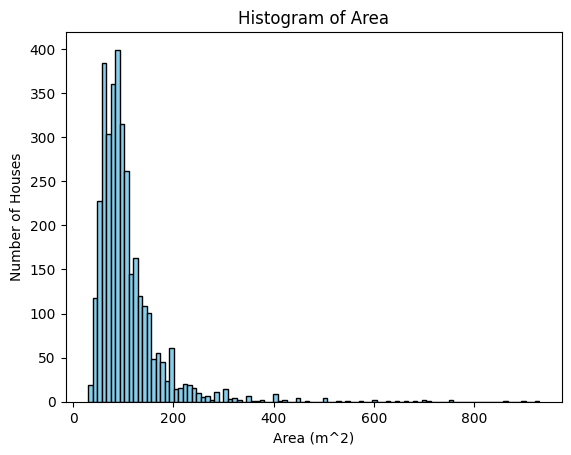

In [5]:
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
outliers_count = df[df['Area'] > 250].shape[0]
print(f"\nThe number of Houses with more than 250 m^2: {outliers_count}\n")

plt.hist(df['Area'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Area')
plt.xlabel('Area (m^2)')
plt.ylabel('Number of Houses')
plt.show()

In [6]:
df = df[df['Area'] <= 250]

### Saving the Cleaned Dataset
We save the processed data to a new file named `housePrice_cleaned.csv`. This allows us to maintain a clear version history and ensures that our machine learning models are trained on high-quality, pre-processed information without modifying the original raw data.

In [7]:
df.to_csv('housePrice_cleaned.csv', index=False)

print("The cleaned dataset has been saved successfully as 'housePrice_cleaned.csv'.")

The cleaned dataset has been saved successfully as 'housePrice_cleaned.csv'.
